2026-06-23 13:15:46,418 - DEBUG    - preprocess json (1019790582.py:29)
2026-06-23 13:15:46,419 - DEBUG    - flatten json into df (1019790582.py:32)
2026-06-23 13:15:46,466 - DEBUG    - before prefix features: category_rank, combat_lvl_value, is_bot, misc_amoxliatl_kc, misc_amoxliatl_rank, misc_araxxor_kc, misc_araxxor_rank, misc_armadyl_kc, misc_armadyl_rank, misc_artio_kc, misc_artio_rank, misc_bandos_kc, misc_bandos_rank, misc_barrows_chests_kc, misc_barrows_chests_rank, misc_bh_hunter_kc, misc_bh_hunter_rank, misc_bh_legacy_hunter_kc, misc_bh_legacy_hunter_rank, misc_bh_legacy_rogue_kc, misc_bh_legacy_rogue_rank, misc_bh_rogue_kc, misc_bh_rogue_rank, misc_brutus_kc, misc_brutus_rank, misc_bryophyta_kc, misc_bryophyta_rank, misc_callisto_kc, misc_callisto_rank, misc_calvarion_kc, misc_calvarion_rank, misc_cerberus_kc, misc_cerberus_rank, misc_cg_kc, misc_cg_rank, misc_chaos_elemental_kc, misc_chaos_elemental_rank, misc_chaos_fanatic_kc, misc_chaos_fanatic_rank, misc_clue_all_kc, mis

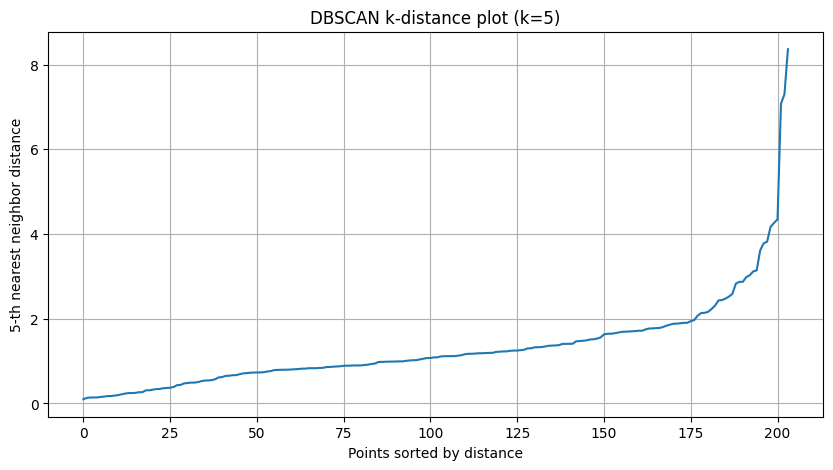

Median k-distance: 1.087187836507299
90th percentile k-distance: 2.394967253135907
97th percentile k-distance: 3.812982632474056
Suggested eps (90th percentile): 2.395
Suggested eps (97th percentile): 3.813


In [ ]:
import json
import os

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np

from osrs_anomaly_ml.util import features
from osrs_anomaly_ml.util.log import get_logger
from osrs_anomaly_ml.util.common import fill_missing_hiscore_data, fill_missing_values_df, flatten_hiscore_record, flatten_json_to_df, normalize_number, prefix_columns, read_data_dump
from dotenv import load_dotenv
load_dotenv(override=True)

logger = get_logger(__name__)
PCA_DEFAULT_SIZE = 30
USE_PCA = False

# make a .env file in project root or use BACKUP_IN_FILE
BACKUP_IN_FILE=os.path.join('..', 'data', 'corp_anonymized.txt')
in_file = os.getenv("NOTEBOOK_IN_FILE", BACKUP_IN_FILE)

data_json = read_data_dump(in_file)

# rename rank to total rank to remove confusion with category rank
# flatten 'record' json 'property'
logger.debug('preprocess json')
data = flatten_hiscore_record(data_json)

logger.debug('flatten json into df')
df = flatten_json_to_df(data, sep="_")

logger.debug("before prefix features: " + ", ".join(sorted(df.columns)))

logger.debug('prefix columns')
df = prefix_columns(df)

logger.debug("after prefix features: " + ", ".join(sorted(df.columns)))

logger.debug('fill missing values df')
df = fill_missing_values_df(df)
# todo: add missing skills, misc and bosses
# dataset is large enough atm that there are no missing values
df = fill_missing_hiscore_data(df)

logger.debug('normalize numeric')
df = df.map(normalize_number)

# can maybe keep combat lvl float
float_cols = df.select_dtypes(include="float64").columns
float_cols = float_cols.drop("is_bot", errors="ignore")
df[float_cols] = df[float_cols].astype("int64")


logger.debug('Start FE')
logger.debug('FE: add ratios')
df = features.add_username_ratio(df) # WOP
df = features.add_combat_ratio_lvl(df)
df = features.add_combat_ratio_xp(df) 
df = features.add_skill_ratios(df)
df = features.add_boss_ratios(df)

logger.debug('FE: add patterns')
df = features.add_scurrius_corp_pattern(df)

logger.debug('FE: log transform')
df = features.transform_skill_xp_to_log(df)

logger.debug('FE: Apply weights')
weights = {
    # "combat_ratio_lvl_missing_flag": 1,
}
df = features.apply_feature_weights(df, weights)

logger.debug('FE: Add soft features')
df = features.add_soft_features(
    df,
    # cols=["combat_ratio_xp_missing_flag"],
    cols=["total_lvl"],
    prefix="log_",
    method="log1p"
)

logger.debug('FE: remove columns')
df = features.remove_total_category_ranks(df)
# skills
df = features.remove_lvl(df, "skill_")
df = features.remove_xp(df, "skill_")
df = features.remove_rank(df, "skill_")

df = features.remove_lvl(df, "log_skill_")
df = features.remove_xp(df, "log_skill_")
df = features.remove_rank(df, "log_skill_")

df = features.remove_xp(df, "total_")
df = features.remove_xp(df, "log_total")
df = features.remove_xp(df, "log_combat")

# misc
df = features.remove_rank(df, "misc_")
df = features.remove_kc(df, "misc_")

# boss
df = features.remove_rank(df, "boss_")
df = features.remove_rank(df, "log_boss")
df = features.remove_kc(df, "boss_")
df = features.remove_kc(df, "log_boss")

df = df.sort_index(axis=1)

# df = features.remove(df, [
#     "combat_lvl_value", 
#     "combat_ratio_lvl_missing_flag", 
#     "combat_ratio_xp_missing_flag", 
#     "total_boss_kc",
#     "top1_boss_kc",
#     "top2_boss_kc_sum",
#     "total_level",
#     "xp_per_lvl",
#     "non_combat_xp",
#     "construction_vs_other_noncombat_xp_ratio",
#     ])

# Numeric only
df_numeric = df.select_dtypes(include=[np.number]).copy()
logger.debug('FE: remove is bot flag from numeric')
df_numeric = features.remove(df_numeric, ["is_bot"])


logger.debug("df features: " + ", ".join(sorted(df.columns)))
logger.debug("numeric features: " + ", ".join(sorted(df_numeric.columns)))


scaler = StandardScaler()
X = scaler.fit_transform(df_numeric)

if USE_PCA:
    logger.debug('create PCA with float32')
    max_components = min(X.shape[0], X.shape[1])
    n_components = min(PCA_DEFAULT_SIZE, max_components)

    if n_components < PCA_DEFAULT_SIZE:
        logger.warning(
            f"Reducing PCA components from {PCA_DEFAULT_SIZE} to {n_components} due to data shape {X.shape}"
        )

    pca = PCA(n_components=n_components)
    X = pca.fit_transform(X)

min_samples = 5
k = min_samples  

nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)

k_distances = np.sort(distances[:, -1]) 


plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.ylabel(f"{k}-th nearest neighbor distance")
plt.xlabel("Points sorted by distance")
plt.title(f"DBSCAN k-distance plot (k={k})")
plt.grid(True)
plt.show()

print("Median k-distance:", np.median(k_distances))
print("90th percentile k-distance:", np.percentile(k_distances, 90))
print("97th percentile k-distance:", np.percentile(k_distances, 97))

eps_90 = np.percentile(k_distances, 90)
eps_97 = np.percentile(k_distances, 97)
print(f"Suggested eps (90th percentile): {eps_90:.3f}")
print(f"Suggested eps (97th percentile): {eps_97:.3f}")